In [2]:
import torch
print(torch.__version__)

2.9.1+cu128


In [2]:
x = torch.tensor(5.0)
y = 3*x**2
print(y)

tensor(75.)


In [5]:
x = torch.tensor(5.0, requires_grad=True)
y = 3*x**2
y.backward()
print(x.grad)

tensor(30.)


In [3]:
def rosenbrock(x0, x1):
    y = 100*(x1 - x0**2)**2 + (x0 -1)**2
    return y

x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)

# x0 = 0.0, x1 = 2.0のときの微分
y = rosenbrock(x0, x1)
y.backward()
print(x0.grad, x1.grad)

tensor(-2.) tensor(400.)


In [5]:
x0 = torch.tensor(0.0, requires_grad=True)
x1 = torch.tensor(2.0, requires_grad=True)

lr = 0.001
iters = 10000

for i in range(iters):
    if i % 1000 == 0:
        print(x0.item(), x1.item())

    y = rosenbrock(x0, x1)
    y.backward()

    # # 値を更新するときはdata_attributeを操作する
    # x0.data -= lr*x0.grad.data
    # x1.data -= lr*x1.grad.data

    # パラメータ更新処理が計算グラフに含まれないようにする
    # 勾配の計算を一時的にオフにする魔法の箱
    with torch.no_grad():
        x0 -= lr*x0.grad
        x1 -= lr*x1.grad

    # 誤った勾配（累積した勾配）を使うことを防ぐ
    x0.grad.zero_()
    x1.grad.zero_()

print(x0.item(), x1.item())

0.0 2.0
0.6837119460105896 0.4659528136253357
0.8263181447982788 0.6820318102836609
0.8947840929031372 0.8001903295516968
0.9334872364997864 0.8711214661598206
0.9569892883300781 0.9156519174575806
0.9718162417411804 0.9443121552467346
0.9813804626464844 0.9630323052406311
0.98763507604599 0.9753732085227966
0.9917610883712769 0.983556866645813
0.9944981336593628 0.9890044331550598


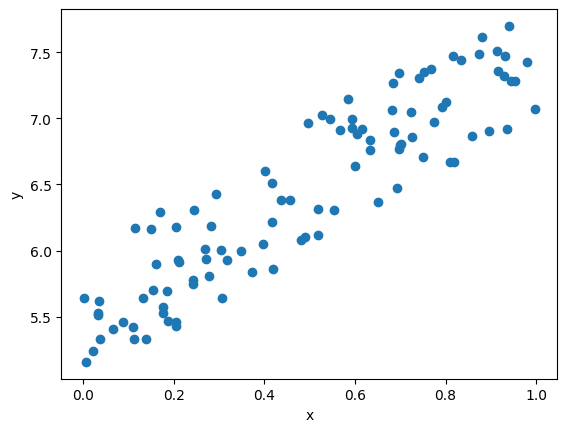

In [8]:
import matplotlib.pyplot as plt

torch.manual_seed(0)
x = torch.rand(100, 1)
y = 2*x + 5 + torch.rand(100, 1)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
ax.scatter(x,y)
ax.set_xlabel('x')
ax.set_ylabel('y')
fig.show()

In [11]:
# x,yには正の相関の関係が予想できる

torch.manual_seed(0)
x = torch.rand(100, 1)
y = 2*x + 5 + torch.rand(100, 1)
W = torch.zeros((1,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)

def predict(x):
    y = x@W + b
    return y

def mean_squared_error(x0, x1):
    diff = x0 - x1
    N = len(diff)
    return torch.sum(diff**2)/N

lr = 0.1
iters = 100

for i in range(iters):
    y_hat = predict(x)
    loss = mean_squared_error(y, y_hat)
    loss.backward()

    with torch.no_grad():
        W -= lr*W.grad
        b -= lr*b.grad

    W.grad.zero_()
    b.grad.zero_()

    if i%10 == 0:
        print(loss.item())
        print('='*4)
        print('W = ', W.item())
        print('b = ', b.item(), '\n')

41.89796447753906
====
W =  0.665682315826416
b =  1.2871865034103394 

0.22483211755752563
====
W =  2.493596076965332
b =  4.935605525970459 

0.0925208106637001
====
W =  2.5405941009521484
b =  5.166225433349609 

0.0888015553355217
====
W =  2.495894193649292
b =  5.203803539276123 

0.08627457916736603
====
W =  2.452197551727295
b =  5.227496147155762 

0.08435674756765366
====
W =  2.413858413696289
b =  5.2476396560668945 

0.0829005315899849
====
W =  2.3804357051849365
b =  5.265163898468018 

0.0817948430776596
====
W =  2.351311445236206
b =  5.28043270111084 

0.08095530420541763
====
W =  2.3259332180023193
b =  5.293737888336182 

0.08031783998012543
====
W =  2.303818941116333
b =  5.305331707000732 



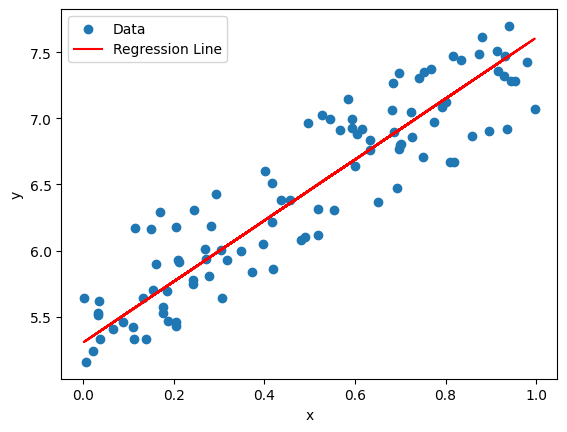

In [14]:
import matplotlib.pyplot as plt
import seaborn

W = 2.303818941116333
b = 5.305331707000732
y_pred = W*x + b

fig = plt.figure()
ax = fig.add_subplot(1,1,1)

ax.scatter(x, y, label='Data')
ax.plot(x, y_pred, color='red', label='Regression Line')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
fig.show()

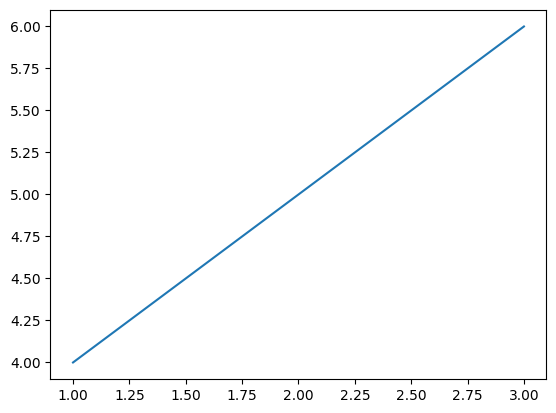

In [15]:
# matplotlibの練習
import matplotlib.pyplot as plt

# 同時にfigとaxを作ってくれる便利な関数。それがsubplots()
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [4, 5, 6])
plt.show()

### matplotlibの練習

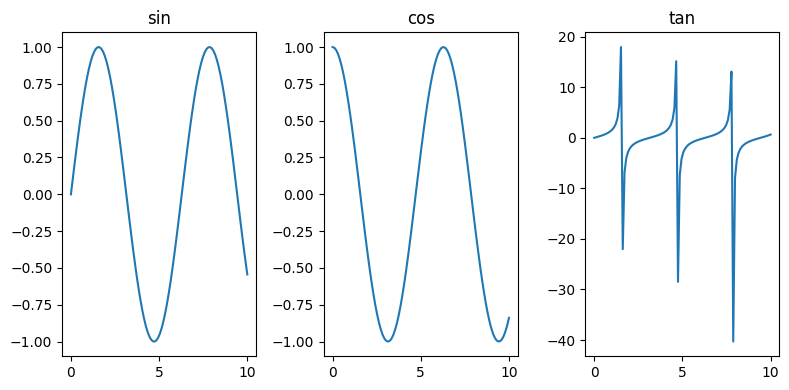

In [20]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)

fig, ax = plt.subplots(1, 3, figsize=(8, 4))

ax[0].plot(x, np.sin(x))
ax[0].set_title("sin")

ax[1].plot(x, np.cos(x))
ax[1].set_title("cos")

ax[2].plot(x, np.tan(x))
ax[2].set_title("tan")

plt.tight_layout()
plt.show()

### Parameter, Module, Linear

In [25]:
import torch
import torch.nn as nn

# nn.Moduleクラスを継承するとmodelインスタンスがparameters()メソッドを使える
class Model(nn.Module):
    def __init__(self):
        # パラメータを登録するための内部辞書を準備
        super().__init__()
        # nn.Parameter型のオブジェクトが自動で学習対象の重みとして内部辞書に登録される
        self.W = nn.Parameter(torch.zeros(1,1))
        self.b = nn.Parameter(torch.zeros(1))
        
    def forward(self, x):
        y = x@self.W + self.b
        return y

model = Model()
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[0.]], requires_grad=True)
Parameter containing:
tensor([0.], requires_grad=True)


In [6]:
# nn.Moduleクラスを継承するとmodelインスタンスがparameters()メソッドを使える
class Model(nn.Module):
    def __init__(self, input_size=1, output_size=1):
        # パラメータを登録するための内部辞書を準備
        super().__init__()
        # nn.Linearクラスもnn.Moduleクラスを継承していて、その中にweightとbiasのnn.Parameterを持っている
        self.linear = nn.Linear(input_size, output_size)
        
    def forward(self, x):
        y = self.linear(x)
        return y

model = Model()
for param in model.parameters():
    print(param)

Parameter containing:
tensor([[-0.7559]], requires_grad=True)
Parameter containing:
tensor([-0.6865], requires_grad=True)


In [4]:
import torch
import torch.nn as nn

# シードを固定する
torch.manual_seed(0)

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

model = Model()
for param in model.parameters():
    print(param) # 何度実行しても同じ値が出るようになります

Parameter containing:
tensor([[-0.0075]], requires_grad=True)
Parameter containing:
tensor([0.5364], requires_grad=True)


### Optimizer

In [9]:
# x,yには正の相関の関係が予想できる

torch.manual_seed(0)
x = torch.rand(100, 1)
y = 2*x + 5 + torch.rand(100, 1)

# W = torch.zeros((1,1), requires_grad=True)
# b = torch.zeros(1, requires_grad=True)

# def predict(x):
#     y = x@W + b
#     return y

# def mean_squared_error(x0, x1):
#     diff = x0 - x1
#     N = len(diff)
#     return torch.sum(diff**2)/N

lr = 0.1
iters = 100
model = Model()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

for i in range(iters):
    y_hat = model(x)
    loss = nn.functional.mse_loss(y, y_hat)
    loss.backward()

    # with torch.no_grad():
    #     W -= lr*W.grad
    #     b -= lr*b.grad

    # W.grad.zero_()
    # b.grad.zero_()

    # パラメータ更新
    optimizer.step()
    # 勾配をリセット
    optimizer.zero_grad()

    if i%10 == 0:
        print(loss.item())
        print('='*4)
        # print('W = ', W.item())
        # print('b = ', b.item(), '\n')
        print('W = ', model.linear.weight)
        print('b = ', model.linear.bias, '\n')

33.76302719116211
====
W =  Parameter containing:
tensor([[0.6421]], requires_grad=True)
b =  Parameter containing:
tensor([1.7988], requires_grad=True) 

0.1873609572649002
====
W =  Parameter containing:
tensor([[2.3055]], requires_grad=True)
b =  Parameter containing:
tensor([5.0619], requires_grad=True) 

0.08291865140199661
====
W =  Parameter containing:
tensor([[2.3674]], requires_grad=True)
b =  Parameter containing:
tensor([5.2586], requires_grad=True) 

0.08156854659318924
====
W =  Parameter containing:
tensor([[2.3445]], requires_grad=True)
b =  Parameter containing:
tensor([5.2833], requires_grad=True) 

0.08078274130821228
====
W =  Parameter containing:
tensor([[2.3202]], requires_grad=True)
b =  Parameter containing:
tensor([5.2967], requires_grad=True) 

0.08018676936626434
====
W =  Parameter containing:
tensor([[2.2989]], requires_grad=True)
b =  Parameter containing:
tensor([5.3079], requires_grad=True) 

0.07973429560661316
====
W =  Parameter containing:
tensor([[

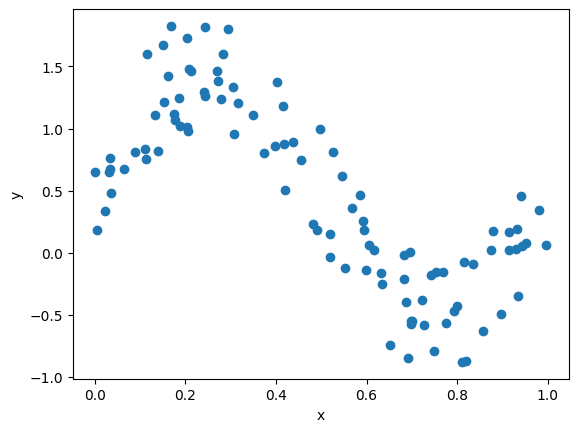

In [56]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
x = torch.rand(100, 1)
y = torch.sin(2 * torch.pi * x) + torch.rand(100, 1)
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_xlabel('x')
ax.set_ylabel('y')
fig.show()

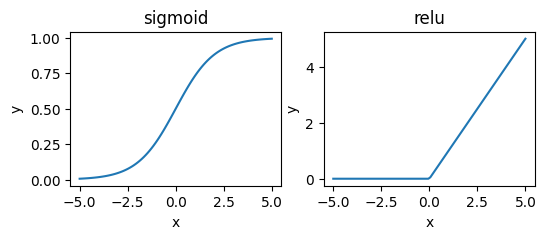

In [16]:
import torch.nn.functional as F

a = torch.linspace(-5, 5, 100).unsqueeze(1)
b = F.sigmoid(a)
c = F.relu(a)

fig, ax = plt.subplots(1, 2, figsize=(6,2))
ax[0].plot(a, b)
ax[0].set_title('sigmoid')
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')

ax[1].plot(a, c)
ax[1].set_title('relu')
ax[1].set_xlabel('x')
ax[1].set_ylabel('y')
fig.show()

In [22]:
# 指定した位置にサイズ1の次元を追加するunsqueeze(dim=...)
print(torch.rand(3,3).unsqueeze(1).shape)
print(torch.linspace(-5,5,10).shape)
print(torch.linspace(-5,5,10).unsqueeze(1).shape)

torch.Size([3, 1, 3])
torch.Size([10])
torch.Size([10, 1])


In [23]:
# ランダムで、負の数が含まれないため、グラフの形が崩れる
print(torch.rand(4, 1))
# 昇順で等間隔のためグラフがきれいにかける
print(torch.linspace(-5, 5, 4))

tensor([[0.8970],
        [0.5082],
        [0.1256],
        [0.2257]])
tensor([-5.0000, -1.6667,  1.6667,  5.0000])


In [60]:
import torch.nn as nn
import torch.nn.functional as F

class Model(nn.Module):
    def __init__(self, input_size=1, hidden_size=10, output_size=1):
        super().__init__()
        self.linear1 = nn.Linear(input_size, hidden_size)
        self.linear2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        y = self.linear1(x)
        y = F.sigmoid(y)
        y = self.linear2(y)
        # 0 < sigmoid(x) < 1でクリップすると-1 <= sin(x) <= 1を近似できない
        # y = F.sigmoid(y) <=いらない
        return y

In [61]:
# 学習率が大きすぎる（例：0.3）と振動する・収束しない
lr = 0.01
iters = 10000

model = Model()
# SGDは非線形問題では止まりやすい
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for i in range(iters):
    y_pred = model(x)
    loss = F.mse_loss(y, y_pred)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if i % 1000 == 0:
        print(loss.item())
        print('weight of linear1 : ', model.linear1.weight)
        print('weight of linear2 : ', model.linear2.weight)
        print('='*4)

1.4726861715316772
weight of linear1 :  Parameter containing:
tensor([[ 0.9507],
        [ 0.6838],
        [-0.4460],
        [-0.2417],
        [-0.9626],
        [-0.0280],
        [-0.7631],
        [-0.7814],
        [-0.0651],
        [ 0.1401]], requires_grad=True)
weight of linear2 :  Parameter containing:
tensor([[ 0.1341,  0.0289, -0.1443,  0.1596, -0.2933, -0.1774, -0.0692, -0.1440,
         -0.1006, -0.2492]], requires_grad=True)
====
0.15405401587486267
weight of linear1 :  Parameter containing:
tensor([[-0.2202],
        [-1.5255],
        [-1.1244],
        [-1.4180],
        [-2.0263],
        [-1.3029],
        [-9.7655],
        [-3.6894],
        [-2.0319],
        [-0.6079]], requires_grad=True)
weight of linear2 :  Parameter containing:
tensor([[-0.0256, -0.1886, -0.1338,  0.1214, -0.3465, -0.2707,  1.8759, -0.0782,
         -0.2494, -0.2666]], requires_grad=True)
====
0.09476982802152634
weight of linear1 :  Parameter containing:
tensor([[  0.5908],
        [ -2.6

In [38]:
type(model(x))

torch.Tensor

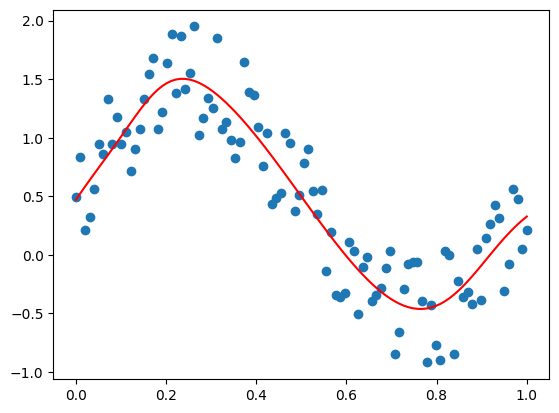

In [62]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
x = torch.linspace(0, 1, 100).reshape(-1, 1)
# matplotlibはnumpy配列を受け取る
pred_y = model(x).detach().numpy()
torch.manual_seed(0)
y = torch.sin(2 * torch.pi * x) + torch.rand(100, 1)
ax.plot(x, pred_y, color='red')
ax.scatter(x, y)
fig.show()